# Team book — all four workstreams on the combined book's terms

Reza, Jack, Hoshea and Aaryen each built an intraday strategy around scheduled US macro
releases, but on different data, years, entry rules and costs, so their headline numbers
cannot be compared directly. This notebook puts **one book from each person** on the same
terms as `backtest.py`, compares them row for row, measures how much their daily P&L
overlaps, and combines them into a **team portfolio**.

## Methodology

### 1. The four books

| person | book | direction | releases and windows | source |
|---|---|---|---|---|
| **Reza** | surprise, top-10 releases | sign of the consensus surprise (actual − Bloomberg median, causal z-score) | top-10 release families by marginal impact, plus CPI; one 30-min window after the print | `Reza/src` (same pipeline as `surprise_dtw_book.py`) |
| **Reza** | CPI surprise model | sign of the predicted CPI move, traded only if it exceeds the round-trip cost | CPI only; one 30-min window | `Reza/src` |
| **Jack** | DTW event reaction book | sign of `dtw_dir`, outer 60% only, size `median(dtw_disp) / dtw_disp` capped at 2 | 8 release families, five back-to-back 30-min windows (T+1 … T+121) | `output/features.parquet` if `features.py` has been run; otherwise a rebuild from the original ES book's specification (`Reza/src/team_replication.py`) |
| **Hoshea** | DTW event games | sign of his DTW factor, one contract | Jobless Claims, JOLTS and PCE (his best group also lists FOMC, but the saved file has no FOMC games); games at T−60 … T+60, each trading the 30 minutes after a 60-minute path | `hoshea_zeng/outputs/dtw_simple_generalized_best_factor.parquet` (his best grid setting) |
| **Aaryen** | 30-minute classifier | his walk-forward position (between −1 and +1) | ~50 releases a year, one 30-min window | `aaryen_backtest_predictions_30min.parquet` |

**Markets.** Reza's and Jack's books exist on **ES, NQ and ZN**, so they are run on all three.
Reza's surprise books also run on **YM** (E-mini Dow) when its cleaned file exists
(`combined/pull.py --pull YM`, then `cleaning.py`); Jack's DTW book has not been built on YM.
Hoshea's and Aaryen's work exists on **ES only**, so they appear on ES only. The team
portfolios use every book that exists, on every market.

**Jack's equities book.** Besides his single-market books, Jack's current `backtest.py`
combines ES and NQ with **inverse-vol weights and a cost gate** (each day an asset's weight is
1 / its trailing 60-session volatility, or 0 if a round trip costs more than 10% of its
median 30-minute move over the past year). That book is rebuilt here from his ES and NQ
books with the same rule, and shown next to the team portfolios.

Each person's **own positions** are kept exactly as they built them. Only the return, the
cost and the scoring are recomputed here, from the same cleaned bars.

### 2. The common terms (the same as `backtest.py`)

* **Prices:** Jack's cleaned 1-minute bars (`futures_1min_clean_v3_{ES,NQ,ZN}.parquet`), with the
  price jump at each contract roll removed.
* **Executable entry:** every trade enters at the close of a bar that ends *after* the
  release is public. For Aaryen this means **one minute later than in his own backtest**
  (his reported version enters at the price before the release, which no one can trade).
  Both versions are shown; only the executable one is used in the portfolios.
* **Costs:** gross, a quarter tick and half a tick per side (`config.py`), plus
  2 ticks round trip + $4.50 commission (Reza's base case). Cost is charged on the size
  traded: |position| × round-trip cost in bps at the entry price.
* **Metrics:** P&L in bps of one contract's notional, summed per trading session
  (18:00–17:00 ET), zero on days with no trade; Sharpe, return and volatility annualised
  over 252 sessions; max drawdown; beta to the market's own buy-and-hold.

### 3. The periods

* **Validation 2018–2020** and **test 2021–2026**, as in `config.py`.
* Reza's and Jack's books are walk-forward (refit each year on earlier years only).
  Aaryen's positions are walk-forward in his own pipeline.
* **Caveat on Hoshea's book:** his factor setting was chosen on the full sample, so it
  contains some in-sample selection in both periods.
* **Caveat on the test years:** they have already been looked at in earlier notebooks, so
  they are not an untouched test for any book. Nothing is tuned on them here.

### 4. How the books are combined

1. **Overlap:** the correlation of daily net P&L between books. Low correlation means the
   books trade different things and can diversify each other.
2. **Equal-risk team portfolios:** each book is weighted by 1 / its daily volatility, with
   the weights taken from the **validation years only** (at a quarter tick), and scored on
   the test years. Five portfolios:
   * **Team, all markets:** every book on every market: the four ES books, plus Reza's and
     Jack's books on NQ and ZN.
   * **Team, ES + NQ:** the same without ZN, whose edge does not survive costs in either
     workstream.
   * **Team, ES (all four):** Reza's top-10 surprise book, Jack's DTW book, Hoshea's DTW event
     games and Aaryen's executable classifier.
   * **Reza + Jack (ES):** surprise direction plus the DTW ladder.
   * **Reza + Hoshea (ES):** a coverage split: Reza's surprise covers the main data releases, Hoshea's
     DTW adds weekly Jobless Claims, JOLTS and PCE, with games before and after the print.
   * When YM is available: **Team, equities (ES + NQ + YM)** (every equity book) and
     **Reza, ES + NQ + YM (surprise)** (the macro-surprise book on the three equity indices).
3. The portfolios change no one's positions; they only size each book by its risk.

### 5. Outputs

`output/team_book_summary.csv` (all metric tables), `output/team_book_correlation.csv`,
`output/team_book_cumulative.png`.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = HERE.parent
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(ROOT / "Reza"))                  # Reza's pipeline: Reza/src
from config import (ALL_ASSETS, BLOOMBERG, BOOK_SYMBOLS, CLEAN_BARS_FMT, COST_TICKS_PER_SIDE, EXTRA_ASSETS,
                    NY, OUT, PANEL, SESSION_SHIFT, TEST_YEARS_SPAN, TRAIN_YEARS_SPAN, VALID_YEARS_SPAN)
ASSETS = ALL_ASSETS                                     # contract specs for every market, YM included
import src.surprise_universe as su
import src.state_conditioning as sc
import src.team_replication as tr

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", None)

PROJECT = ROOT.parent / ("BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-"
                         "to-Macroeconomic-Surprises")


def first_existing(paths, what):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError(f"{what} not found in: {[str(p) for p in paths]}")


BBG_FILE = first_existing([BLOOMBERG, PROJECT / "data/raw/Bloomberg Economic Releases.xlsx"],
                          "Bloomberg file")
HOSHEA_FILE = first_existing([ROOT / "hoshea_zeng/outputs/dtw_simple_generalized_best_factor.parquet",
                              PROJECT / "data/team_inputs/dtw_simple_generalized_best_factor.parquet"],
                             "Hoshea's factor file")
AARYEN_FILE = first_existing([ROOT / "aaryen/data/backtest_predictions_30min.parquet",
                              PROJECT / "data/team_inputs/aaryen_backtest_predictions_30min.parquet"],
                             "Aaryen's 30-minute predictions")
AARYEN_WINDOW = 30

HIST_START = f"{TRAIN_YEARS_SPAN[0]}-01-01"
WF_YEARS = list(range(VALID_YEARS_SPAN[0], TEST_YEARS_SPAN[1] + 1))
PERIODS = {"validation": VALID_YEARS_SPAN, "test": TEST_YEARS_SPAN}
K_FAMILIES, MIN_TRAIN, THRESHOLD = 10, 24, 1.0          # fixed in Reza/, not tuned here
CPI = "CPI"
JACK_Q, JACK_MAX_POS = 0.30, 2.0                        # original ES book: outer 60%, cap 2

# cost levels: (ticks round trip, commission $ round trip); the first three are config.py's
COSTS = {name: (2 * t, 0.0) for name, t in COST_TICKS_PER_SIDE.items()}
COSTS["2 ticks + $4.50"] = (2.0, 4.5)
TUNE_COST = "quarter tick"

for label, p in [("Bloomberg", BBG_FILE), ("Hoshea", HOSHEA_FILE), ("Aaryen", AARYEN_FILE),
                 ("Jack's panel", PANEL)]:
    print(f"{label:<13s} {p}  exists: {Path(p).exists()}")

Bloomberg     /Users/reza/Desktop/mfe-term_3/blackrock-intraday/data/raw/Bloomberg Economic Releases.xlsx  exists: True
Hoshea        /Users/reza/Desktop/mfe-term_3/blackrock-intraday/hoshea_zeng/outputs/dtw_simple_generalized_best_factor.parquet  exists: True
Aaryen        /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/team_inputs/aaryen_backtest_predictions_30min.parquet  exists: True
Jack's panel  /Users/reza/Desktop/mfe-term_3/blackrock-intraday/combined/output/features.parquet  exists: True


## 1. Prices, sessions and costs

The same cleaned bars for everyone. `asof(t, x)` reads a series at the close of the bar
labelled `t` (or the last bar before it, at most 5 minutes stale).

In [2]:
def session_of(ts) -> pd.Series:
    """The trading session a timestamp belongs to (18:00-17:00 ET, dated by the close)."""
    ts = pd.Series(pd.DatetimeIndex(ts))
    return (ts.dt.tz_convert(NY) + SESSION_SHIFT).dt.normalize().dt.tz_localize(None)


def load_market(s: str):
    b = pd.read_parquet(CLEAN_BARS_FMT.format(symbol=s))
    b.index = pd.to_datetime(b.index, utc=True)
    b = b.sort_index()
    if "session_date" not in b.columns:
        b["session_date"] = session_of(b.index).to_numpy()
    bars = sc.prepare_es_minute(b[["close", "contract"]].rename(columns={"contract": "instrument_id"}))
    adj, _ = sc.build_adjusted_log_price(bars)
    return b, adj


class Asof:
    def __init__(self, adj):
        idx = adj.index.as_unit("ns") if hasattr(adj.index, "as_unit") else adj.index
        self.t = idx.asi8
        self.lp = adj["logp_adj"].to_numpy()
        self.close = adj["close"].to_numpy()

    def __call__(self, ts, what="lp"):
        ts = pd.DatetimeIndex(pd.to_datetime(ts, utc=True))
        ts = ts.as_unit("ns") if hasattr(ts, "as_unit") else ts
        pos = np.searchsorted(self.t, ts.asi8, side="right") - 1
        ok = (pos >= 0) & ((ts.asi8 - self.t[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
        arr = self.lp if what == "lp" else self.close
        return np.where(ok, arr[np.clip(pos, 0, None)], np.nan)


def cost_bps(price, cost: str, s: str = "ES") -> np.ndarray:
    ticks_rt, comm = COSTS[cost]
    return (ticks_rt * ASSETS[s]["tick"] + comm / ASSETS[s]["point_value"]) / np.asarray(price, float) * 1e4


def buy_and_hold(b: pd.DataFrame) -> pd.Series:
    """Daily bps from holding one contract, skipping the jump at each roll."""
    r = np.log(b.close).diff() * 1e4
    r[b.contract.ne(b.contract.shift())] = 0.0
    return r.fillna(0.0).groupby(pd.DatetimeIndex(b.session_date)).sum()


bars, adj, asof, bnh = {}, {}, {}, {}
JACK_MARKETS = list(BOOK_SYMBOLS)                       # the DTW book's markets (ES, NQ, ZN)
EXTRA_MARKETS = [s for s in EXTRA_ASSETS if Path(CLEAN_BARS_FMT.format(symbol=s)).exists()]
MARKETS = JACK_MARKETS + EXTRA_MARKETS                  # + YM once its cleaned file exists
print("markets:", MARKETS, "| Jack's DTW book on:", JACK_MARKETS)
for s in MARKETS:
    bars[s], adj[s] = load_market(s)
    asof[s] = Asof(adj[s])
    bnh[s] = buy_and_hold(bars[s])
    print(f"{s}: {len(bars[s]):,} bars, {bars[s].index.min().date()} to {bars[s].index.max().date()}")

markets: ['ES', 'NQ', 'ZN', 'YM'] | Jack's DTW book on: ['ES', 'NQ', 'ZN']


ES: 5,392,615 bars, 2010-07-01 to 2026-06-30


NQ: 5,255,764 bars, 2010-07-01 to 2026-06-30


ZN: 5,392,031 bars, 2010-07-01 to 2026-06-30


YM: 5,195,343 bars, 2010-07-01 to 2026-06-30


## 2. The books

Every book becomes the same trade log: `entry` (the bar whose close is the entry price),
`position`, `ret_bps` (log return from entry to exit, in bps), `price` (for costs) and
`market`. Only Reza's CPI model has positions that depend on the cost level, because the
cost is its trade/no-trade threshold, so every book is stored per cost level.

In [3]:
rows = su.load_bloomberg(BBG_FILE)
fam = su.build_families(rows)
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
books: dict[str, dict[str, pd.DataFrame]] = {}


def trade_log(entry, position, ret_bps, price, market="ES") -> pd.DataFrame:
    t = pd.DataFrame({"entry": pd.DatetimeIndex(pd.to_datetime(entry, utc=True)),
                      "position": np.asarray(position, float), "ret_bps": np.asarray(ret_bps, float),
                      "price": np.asarray(price, float), "market": market})
    t = t[(t.position != 0) & np.isfinite(t.position) & np.isfinite(t.ret_bps) & np.isfinite(t.price)]
    t["year"] = t["entry"].dt.tz_convert(NY).dt.year
    t["session"] = session_of(t["entry"]).to_numpy()
    return t.sort_values("entry").reset_index(drop=True)


# ---- Reza: walk-forward surprise books (the same pipeline as surprise_dtw_book.py)
def reza_market(s: str) -> dict:
    ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
    px = su.price_measures(adj[s], ts_all)
    screens, admitted, signs, hist = {}, {}, {}, {}
    for y in WF_YEARS:
        screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
        admitted[y] = set(screens[y].head(K_FAMILIES)["family"]) if len(screens[y]) else set()
        signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
        hist[y] = su.history_panel(surp, fam, px, admitted[y] | {CPI}, signs[y], HIST_START, f"{y + 1}-01-01")
    fams = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in WF_YEARS}
    panel = su.family_signal_panel(surp, fam, px, fams, signs, WF_YEARS)
    panel["year"] = panel["ts_utc"].dt.tz_convert(NY).dt.year
    panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]
    return dict(panel=panel, hist=hist)


def reza_book(res: dict, s: str, model: str, cost: str) -> pd.DataFrame:
    p = res["panel"].copy()
    ticks_rt, comm = COSTS[cost]
    p["cost_bps"] = su.cost_bps(p["pre_close"], ticks_rt, comm, ASSETS[s]["tick"], ASSETS[s]["point_value"])
    sub = p[p["family"] == CPI] if model == "surprise" else p[p["admitted"]]
    t = su.to_trades(su.build_positions(sub, res["hist"], model, "w1", MIN_TRAIN, THRESHOLD), "w1", model)
    T = pd.DatetimeIndex(t["timestamp_utc"])               # entry: close of bar T (one minute after)
    return trade_log(T, t["position"], t["ret_bps"], asof[s](T, "close"), s)


reza = {s: reza_market(s) for s in MARKETS}
for s in MARKETS:
    books[f"Reza · surprise, top-10 ({s})"] = {c: reza_book(reza[s], s, "naive", c) for c in COSTS}
    books[f"Reza · CPI surprise model ({s})"] = {c: reza_book(reza[s], s, "surprise", c) for c in COSTS}
for k in [k for k in books if k.startswith("Reza")]:
    print(f"{k:<34s} {len(books[k][TUNE_COST]):>5,} trades {WF_YEARS[0]}-{WF_YEARS[-1]}")

Reza · surprise, top-10 (ES)         764 trades 2018-2026
Reza · CPI surprise model (ES)        94 trades 2018-2026
Reza · surprise, top-10 (NQ)         761 trades 2018-2026
Reza · CPI surprise model (NQ)        98 trades 2018-2026
Reza · surprise, top-10 (ZN)         683 trades 2018-2026
Reza · CPI surprise model (ZN)        38 trades 2018-2026
Reza · surprise, top-10 (YM)         714 trades 2018-2026
Reza · CPI surprise model (YM)        91 trades 2018-2026


### Jack: the DTW event reaction book

On each market (ES, NQ, ZN): if `features.py` has been run, his own panel is used with the original ES book's rule
(outer 60% of `dtw_dir`, cut-offs from the years before the scored period, size
`median(dtw_disp) / dtw_disp` capped at 2, positions averaged per entry minute). Otherwise
the book is rebuilt from that specification with `Reza/src/team_replication.py` (a close
approximation, not his exact code).

In [4]:
panel_j = pd.read_parquet(PANEL) if Path(PANEL).exists() else None
JACK_SOURCE = ("his features.parquet, original ES rule" if panel_j is not None else
               "rebuild from the original ES book's specification (team_replication.py)")


def jack_book(s: str) -> pd.DataFrame:
    if panel_j is not None and (panel_j.symbol == s).any():
        g = panel_j[(panel_j.symbol == s) & panel_j.admitted & panel_j.dtw_dir.notna()].copy()
        parts = []
        for per, span in PERIODS.items():
            fit = g[g.year.between(TRAIN_YEARS_SPAN[0], span[0] - 1)]
            lo, hi, ref = fit.dtw_dir.quantile(JACK_Q), fit.dtw_dir.quantile(1 - JACK_Q), fit.dtw_disp.median()
            cur = g[g.year.between(*span)].copy()
            size = np.clip(ref / cur.dtw_disp, 0, JACK_MAX_POS)
            cur["position"] = np.where((cur.dtw_dir <= lo) | (cur.dtw_dir >= hi), np.sign(cur.dtw_dir) * size, 0.0)
            cur = (cur[cur.position != 0].groupby("entry_ts")
                   .agg(position=("position", "mean"), fwd_ret=("fwd_ret", "first")).reset_index())
            parts.append(cur)
        j = pd.concat(parts)
        E = pd.DatetimeIndex(j["entry_ts"])                            # his entry bar
        return trade_log(E, j["position"], j["fwd_ret"] * 1e4, asof[s](E, "close"), s)
    jb = tr.jack_ladder_book(rows, fam, adj[s], hist_start="2010-01-01", eval_years=WF_YEARS, verbose=False)
    E = pd.DatetimeIndex(jb["entry_time"]) - pd.Timedelta(minutes=1)
    return trade_log(E, jb["position"], jb["ret_bps"], jb["price"], s)


for s in JACK_MARKETS:
    jl = jack_book(s)
    books[f"Jack · DTW event reaction book ({s})"] = {c: jl for c in COSTS}
    print(f"Jack ({s}): {JACK_SOURCE}; {len(jl):,} trades {WF_YEARS[0]}-{WF_YEARS[-1]}")

Jack (ES): his features.parquet, original ES rule; 1,702 trades 2018-2026
Jack (NQ): his features.parquet, original ES rule; 1,586 trades 2018-2026
Jack (ZN): his features.parquet, original ES rule; 2,484 trades 2018-2026


### Hoshea: DTW event games

Each game is an anchor `T0` around a release; the DTW path runs over `[T0, T0+60]` and the
trade is the next 30 minutes, `[T0+60, T0+90]`, one contract in the sign of his factor.
The return is recomputed from the cleaned bars and checked against his own `future_logret`.

In [5]:
hb = pd.read_parquet(HOSHEA_FILE)
hb["t0_utc"] = pd.to_datetime(hb["t0_utc"], utc=True)
E = hb["t0_utc"] + pd.Timedelta(minutes=60)
ret = (asof["ES"](E + pd.Timedelta(minutes=30)) - asof["ES"](E)) * 1e4
ok = np.isfinite(ret) & hb["future_logret"].notna().to_numpy()
print(f"Hoshea: {len(hb):,} games, {hb['t0_utc'].min().date()} to {hb['t0_utc'].max().date()}"
      + (f", event types {sorted(hb['event_type'].unique())}" if "event_type" in hb else ""))
print(f"correlation of the recomputed return with his future_logret: "
      f"{np.corrcoef(ret[ok], hb['future_logret'].to_numpy()[ok])[0, 1]:.3f} (should be close to 1)")
hoshea_log = trade_log(E, np.sign(hb["dtw_factor"]), ret, asof["ES"](E, "close"))
books["Hoshea · DTW event games (ES)"] = {c: hoshea_log for c in COSTS}

Hoshea: 4,749 games, 2012-09-28 to 2026-06-30, event types ['Initial Jobless Claims', 'JOLTS', 'PCE']
correlation of the recomputed return with his future_logret: 1.000 (should be close to 1)


### Aaryen: 30-minute classifier

His walk-forward positions are kept. **Executable:** enter at the close of the release
minute (the first price after the print) and exit 30 minutes later. **As reported:** enter
at the price one minute before the release, as in his own backtest; shown for reference
only, because that price is not tradeable.

In [6]:
ab = pd.read_parquet(AARYEN_FILE)
T = pd.DatetimeIndex(pd.to_datetime(ab["timestamp_utc"], utc=True))
w = pd.Timedelta(minutes=AARYEN_WINDOW)
one = pd.Timedelta(minutes=1)
r_exec = (asof["ES"](T + w) - asof["ES"](T)) * 1e4
r_rep = (asof["ES"](T + w - one) - asof["ES"](T - one)) * 1e4
if "trade_return" in ab:
    ok = np.isfinite(r_rep) & ab["trade_return"].notna().to_numpy()
    print(f"correlation of the as-reported return with his trade_return: "
          f"{np.corrcoef(r_rep[ok], ab['trade_return'].to_numpy()[ok])[0, 1]:.3f} (should be close to 1)")
books["Aaryen · classifier 30m, executable (ES)"] = {
    c: trade_log(T, ab["position"], r_exec, asof["ES"](T, "close")) for c in COSTS}
books["Aaryen · classifier 30m, as reported (ES)"] = {
    c: trade_log(T - one, ab["position"], r_rep, asof["ES"](T - one, "close")) for c in COSTS}
print(f"Aaryen: {len(ab):,} predictions, {T.min().date()} to {T.max().date()}")

TEAM = ["Reza · surprise, top-10 (ES)", "Jack · DTW event reaction book (ES)",
        "Hoshea · DTW event games (ES)", "Aaryen · classifier 30m, executable (ES)"]
OTHER = [f"{who} ({s})" for s in [m for m in MARKETS if m != "ES"]
         for who in ["Reza · surprise, top-10", "Jack · DTW event reaction book"]
         if f"{who} ({s})" in books]
TEAM_ALL = TEAM + OTHER                                   # every tradeable book, every market
ALL = TEAM_ALL + [f"Reza · CPI surprise model ({s})" for s in MARKETS] + [
    "Aaryen · classifier 30m, as reported (ES)"]


def mkt_of(book: str) -> str:
    return book[-3:-1]

correlation of the as-reported return with his trade_return: 0.999 (should be close to 1)
Aaryen: 507 predictions, 2016-11-17 to 2026-07-14


**Findings:** 2018-2026. **ES:** Reza's top-10 surprise book makes 764 trades (~85 a year) and the CPI model 94; the rebuild of Jack's book 2,585 (~290 a year); Hoshea's file has 4,749 games from 2012 (~375 a year) on Jobless Claims, JOLTS and PCE (no FOMC games); Aaryen's file has 507 predictions from late 2016 (~52 a year). **NQ and ZN** (Reza and Jack only): Reza 761 and 683 trades, Jack 2,665 and 2,576. The recomputed returns match Hoshea's own (correlation 1.000) and Aaryen's as-reported ones (0.999), which confirms that Aaryen's backtest enters at the price before the release.

## 3. Coverage: how often each book trades

In [7]:
cov = pd.DataFrame({b: books[b][TUNE_COST].groupby("year").size() for b in ALL}).T.fillna(0).astype(int)
cov = cov[[c for c in cov.columns if c >= WF_YEARS[0]]]
print("Trades per year (a quarter tick):")
print(cov.to_string())

STRATEGY = {"Reza · surprise, top-10": "Macro-surprise book", "Reza · CPI surprise model": "CPI surprise model",
            "Jack · DTW event reaction book": "DTW ladder book", "Hoshea · DTW event games": "DTW event-game book",
            "Aaryen · classifier 30m, executable": "Machine-learning classifier"}
where = pd.DataFrame("–", index=[f"{k.split(' · ')[0]} · {v}" for k, v in STRATEGY.items()], columns=MARKETS)
for k, v in STRATEGY.items():
    for m in MARKETS:
        if f"{k} ({m})" in books:
            where.loc[f"{k.split(' · ')[0]} · {v}", m] = "✓"
print("\nWhich strategy exists on which market:")
print(where.to_string())

Trades per year (a quarter tick):
year                                       2018  2019  2020  2021  2022  2023  2024  2025  2026
Reza · surprise, top-10 (ES)                 83    78    76   100    99   103   100    83    42
Jack · DTW event reaction book (ES)         143   166   191   204   178   166   270   244   140
Hoshea · DTW event games (ES)               375   360   382   380   380   380   365   330   190
Aaryen · classifier 30m, executable (ES)     49    51    54    55    56    55    54    49    29
Reza · surprise, top-10 (NQ)                 75    88    70    95   118    86    94    83    52
Jack · DTW event reaction book (NQ)         143   148   154   205   208   210   169   239   110
Reza · surprise, top-10 (ZN)                 78    90    97    99    97    71    63    63    25
Jack · DTW event reaction book (ZN)         182   190   167   243   290   332   431   419   230
Reza · surprise, top-10 (YM)                 86    80    65    97   100    81    84    79    42
Reza ·

## 4. Metrics — the same definitions as `backtest.py`

In [8]:
def metrics(daily: pd.Series, bench: pd.Series, t: pd.DataFrame | None = None,
            col: str | None = None) -> dict:
    ann = daily.mean() * 252 / 100
    vol = daily.std(ddof=1) * np.sqrt(252) / 100
    eq = daily.cumsum()
    out = {"total %": daily.sum() / 100, "ann return %": ann, "ann vol %": vol,
           "sharpe": ann / vol if vol else np.nan,
           "max DD %": float((eq - eq.cummax()).min()) / 100,
           "beta": float(np.cov(daily, bench)[0, 1] / bench.var()) if bench.var() else np.nan}
    if t is None:
        out |= {"trades": np.nan, "win rate": float((daily > 0).mean()), "% long": 1.0}
    else:
        n = len(t)
        out |= {"trades": n, "win rate": float((t[col] > 0).mean()) if n else np.nan,
                "% long": float((t.position > 0).mean()) if n else np.nan}
    return out


def in_years(days: pd.DatetimeIndex, span) -> pd.DatetimeIndex:
    return days[(days.year >= span[0]) & (days.year <= span[1])]


def with_net(t: pd.DataFrame, cost: str) -> pd.DataFrame:
    t = t.copy()
    s = t["market"].iloc[0] if len(t) else "ES"
    t["net_bps"] = t.position * t.ret_bps - t.position.abs() * cost_bps(t.price, cost, s)
    return t


def daily(book: str, cost: str, days: pd.DatetimeIndex) -> pd.Series:
    t = with_net(books[book][cost], cost)
    return t.groupby("session")["net_bps"].sum().reindex(days).fillna(0.0)


DAYS = {per: in_years(bnh["ES"].index, span) for per, span in PERIODS.items()}
tables = {}
for per, span in PERIODS.items():
    rows_m = {}
    for b in ALL:
        mkt = mkt_of(b)
        days = in_years(bnh[mkt].index, span)
        for c in COSTS:
            t = with_net(books[b][c], c)
            t = t[t.year.between(*span)]
            rows_m[(b, c)] = metrics(daily(b, c, days), bnh[mkt].reindex(days), t, "net_bps")
    for mkt in MARKETS:
        days = in_years(bnh[mkt].index, span)
        rows_m[(f"{mkt} buy and hold", "buy and hold")] = metrics(bnh[mkt].reindex(days), bnh[mkt].reindex(days))
    tables[per] = pd.DataFrame(rows_m).T

sharpe = pd.concat({per: tables[per]["sharpe"].unstack()[list(COSTS) + ["buy and hold"]] for per in PERIODS}, axis=1)
print("Sharpe by book, cost level and period:")
print(sharpe.reindex(ALL + [f"{m} buy and hold" for m in MARKETS]).round(2).to_string())

Sharpe by book, cost level and period:
                                          validation                                                      test                                                    
                                               gross quarter tick half tick 2 ticks + $4.50 buy and hold gross quarter tick half tick 2 ticks + $4.50 buy and hold
Reza · surprise, top-10 (ES)                    1.20         1.04      0.88            0.45          NaN  1.18         1.09      0.99            0.74          NaN
Jack · DTW event reaction book (ES)             0.83         0.59      0.36           -0.29          NaN  0.78         0.64      0.49            0.10          NaN
Hoshea · DTW event games (ES)                   0.52         0.26      0.00           -0.71          NaN  0.61         0.42      0.23           -0.29          NaN
Aaryen · classifier 30m, executable (ES)        0.46         0.38      0.30            0.08          NaN  0.99         0.95      0.91            0

**Findings:** At a quarter tick in the test years, **ES:** Reza 1.09, Aaryen (executable) 0.95, Hoshea 0.42, Jack (rebuild) −0.23 (validation 1.04, 0.38, 0.26, −0.25). **NQ:** Reza 0.75, Jack 0.19. **ZN:** Reza −0.16, Jack −0.57; both are positive gross (0.22, 0.68) but one ZN tick is too large for its 30-minute moves. Costs separate the books: at 2 ticks + $4.50 Reza ES (0.74), Aaryen (0.81) and Reza NQ (0.64) hold up, while the high-turnover DTW books fall to −0.29 (Hoshea), −0.85 (Jack ES) and −4.62 (Jack ZN). Aaryen as reported scores 2.45 against 0.95 executable, so most of his reported profit is the untradeable first-minute jump. The Jack rows are a rebuild from the specification, not his code; his own ES book on the `combined-iteration` branch reports 0.64 at a quarter tick on 2021-2026. Run `features.py` first and this notebook will use his exact book.

### Test years (2021–2026), a quarter tick per side, full metrics

In [9]:
COLS = ["trades", "total %", "ann return %", "ann vol %", "sharpe", "max DD %", "win rate", "% long", "beta"]
t_q = tables["test"].xs(TUNE_COST, level=1).reindex(ALL)
print(t_q[COLS].round(3).to_string())

                                           trades  total %  ann return %  ann vol %  sharpe  max DD %  win rate  % long   beta
Reza · surprise, top-10 (ES)                527.0   15.863         2.970      2.734   1.086    -2.624     0.529   0.499 -0.002
Jack · DTW event reaction book (ES)        1202.0   10.925         2.045      3.221   0.635    -5.049     0.500   0.525  0.007
Hoshea · DTW event games (ES)              2025.0   11.623         2.176      5.153   0.422    -6.242     0.515   0.525  0.029
Aaryen · classifier 30m, executable (ES)    298.0    5.994         1.122      1.182   0.950    -1.377     0.570   0.557 -0.004
Reza · surprise, top-10 (NQ)                528.0   14.158         2.651      3.555   0.746    -5.004     0.532   0.498 -0.002
Jack · DTW event reaction book (NQ)        1141.0    2.128         0.398      3.614   0.110    -8.161     0.495   0.527 -0.001
Reza · surprise, top-10 (ZN)                418.0   -1.184        -0.220      1.344  -0.164    -2.585     0.493

**Findings:** Test years, a quarter tick. **ES:** Reza +15.9% (2.7% vol, −2.6% max drawdown); Aaryen (executable) +6.0% (1.2% vol, −1.4%, the highest win rate, 57%); Hoshea +11.6% (5.2% vol, −6.2%); Jack (rebuild) −5.3% (−9.9%). **NQ:** Reza +14.2% (−5.0%), Jack +6.4% (−8.5%). **ZN:** Reza −1.2%, Jack −4.6%. Every book has a beta of about zero to buy-and-hold (max drawdowns −31% ES, −48% NQ, −26% ZN).

## 5. Overlap: correlation of daily net P&L (a quarter tick)

Computed on days when at least one of the two books traded, so days with no trading in
either book do not make the books look more alike than they are.

In [10]:
def overlap_corr(per: str) -> pd.DataFrame:
    D = pd.DataFrame({b: daily(b, TUNE_COST, DAYS[per]) for b in TEAM_ALL})
    out = pd.DataFrame(index=TEAM_ALL, columns=TEAM_ALL, dtype=float)
    for a in TEAM_ALL:
        for b in TEAM_ALL:
            m = (D[a] != 0) | (D[b] != 0)
            out.loc[a, b] = D.loc[m, [a, b]].corr().iloc[0, 1] if m.sum() > 20 else np.nan
    return out


corr = {per: overlap_corr(per) for per in PERIODS}
short = {b: f"{b.split(' · ')[0]} {mkt_of(b)}" for b in TEAM_ALL}
for per in PERIODS:
    print(f"\n{per}:")
    print(corr[per].rename(index=short, columns=short).round(2).to_string())


validation:
           Reza ES  Jack ES  Hoshea ES  Aaryen ES  Reza NQ  Jack NQ  Reza ZN  Jack ZN  Reza YM
Reza ES       1.00    -0.22      -0.01       0.14     0.64     0.02     0.12    -0.07     0.78
Jack ES      -0.22     1.00       0.03      -0.04    -0.18     0.31    -0.04    -0.13    -0.18
Hoshea ES    -0.01     0.03       1.00       0.32     0.07     0.03     0.01     0.02    -0.05
Aaryen ES     0.14    -0.04       0.32       1.00     0.10     0.04     0.04    -0.04     0.16
Reza NQ       0.64    -0.18       0.07       0.10     1.00     0.00     0.07    -0.04     0.43
Jack NQ       0.02     0.31       0.03       0.04     0.00     1.00     0.02    -0.13     0.06
Reza ZN       0.12    -0.04       0.01       0.04     0.07     0.02     1.00     0.13     0.11
Jack ZN      -0.07    -0.13       0.02      -0.04    -0.04    -0.13     0.13     1.00    -0.04
Reza YM       0.78    -0.18      -0.05       0.16     0.43     0.06     0.11    -0.04     1.00

test:
           Reza ES  Jack ES  H

**Findings:** The books barely overlap. In the test years most correlations of daily P&L are between −0.05 and 0.3. The exceptions are the same strategy on two equity markets: Reza ES and NQ at 0.68 (the same releases move both), and Jack ES and NQ at 0.30. Across people the highest are Reza and Aaryen (0.27; both trade the main data releases, and Aaryen's classifier uses surprise features) and Aaryen and Reza ZN (0.31). So the workstreams mostly carry different risks, which is what makes a team portfolio worth building.

## 6. Team portfolios, equal risk

Weights = 1 / daily volatility of each book's net P&L in the validation years (a quarter
tick), normalised to sum to one; scored on the test years. The weights never see the test
years.

In [11]:
PORTFOLIOS = {
    "Team, all markets": TEAM_ALL,
    "Team, ES + NQ": TEAM + [b for b in OTHER if mkt_of(b) == "NQ"],
    "Team, ES (all four)": TEAM,
    "Reza + Jack (ES)": TEAM[:2],
    "Reza + Hoshea (ES)": [TEAM[0], TEAM[2]],
}
if "YM" in MARKETS:
    PORTFOLIOS["Team, equities (ES + NQ + YM)"] = PORTFOLIOS["Team, ES + NQ"] + ["Reza · surprise, top-10 (YM)"]
    PORTFOLIOS["Reza, ES + NQ + YM (surprise)"] = [f"Reza · surprise, top-10 ({m})" for m in ["ES", "NQ", "YM"]]
vol_v = pd.Series({b: daily(b, TUNE_COST, DAYS["validation"]).std() for b in TEAM_ALL})
weights = {name: (1 / vol_v[m]) / (1 / vol_v[m]).sum() for name, m in PORTFOLIOS.items()}
print(pd.DataFrame(weights).rename(index=short).round(3).to_string())

port_rows = {}
bench = bnh["ES"].reindex(DAYS["test"])
for name, members in PORTFOLIOS.items():
    for c in COSTS:
        d = sum(weights[name][b] * daily(b, c, DAYS["test"]) for b in members)
        t = pd.concat([with_net(books[b][c], c) for b in members])
        t = t[t.year.between(*TEST_YEARS_SPAN)]
        port_rows[(name, c)] = metrics(d, bench, t, "net_bps")


# ---- Jack's equities book (ES + NQ) with his own weights: inverse vol + cost gate
JACK_EQ = "Jack · DTW equities book (ES + NQ, his weights)"
VOL_SESSIONS, COST_RATIO_MAX = 60, 0.10


def jack_equities_daily(cost: str, days: pd.DatetimeIndex) -> tuple[pd.Series, pd.DataFrame]:
    """Each day: weight 1 / trailing 60-session vol of the underlying, or 0 if a round trip at
    `cost` is over 10% of the median |30-min move| of the asset's DTW trades in the past year
    (checked monthly), normalised to sum to one. Uses only data before the day."""
    w = {}
    for m in ["ES", "NQ"]:
        t = books[f"Jack · DTW event reaction book ({m})"][cost]
        vol = bnh[m].rolling(VOL_SESSIONS).std().shift(1).reindex(days).ffill()
        gate = {}
        for p in days.to_period("M").unique():
            start = pd.Timestamp(p.start_time, tz="UTC")
            past = t[(t.entry < start) & (t.entry >= start - pd.DateOffset(years=1))]
            price = bars[m].close.iloc[bars[m].index.searchsorted(start) - 1]   # last close before the month
            rt = cost_bps([price], cost, m)[0]
            gate[p] = bool(len(past)) and rt < COST_RATIO_MAX * past.ret_bps.abs().median()
        w[m] = pd.Series([gate[p] for p in days.to_period("M")], index=days) / vol
    W = pd.DataFrame(w).fillna(0.0)
    W = W.div(W.sum(axis=1), axis=0).fillna(0.0)
    d = sum(W[m] * daily(f"Jack · DTW event reaction book ({m})", cost, days) for m in ["ES", "NQ"])
    return d, W


jack_w = {}
for c in COSTS:
    d, jack_w[c] = jack_equities_daily(c, DAYS["test"])
    t = pd.concat([with_net(books[f"Jack · DTW event reaction book ({m})"][c], c) for m in ["ES", "NQ"]])
    t = t[t.year.between(*TEST_YEARS_SPAN)]
    port_rows[(JACK_EQ, c)] = metrics(d, bench, t, "net_bps")
print("Jack's equities book, mean weight ES / NQ by cost level (test years):")
print(pd.DataFrame({c: jack_w[c].mean() for c in COSTS}).round(2).to_string())

for b in TEAM_ALL:
    for c in COSTS:
        port_rows[(b, c)] = tables["test"].loc[(b, c)]
port = pd.DataFrame(port_rows).T
print("\nTest years 2021-2026, Sharpe:")
print(port["sharpe"].unstack().reindex(list(PORTFOLIOS) + [JACK_EQ] + TEAM_ALL)[list(COSTS)].round(2).to_string())
print("\nTest years 2021-2026, a quarter tick:")
print(port.xs(TUNE_COST, level=1).reindex(list(PORTFOLIOS) + [JACK_EQ] + TEAM_ALL)[COLS].round(3).to_string())

           Team, all markets  Team, ES + NQ  Team, ES (all four)  Reza + Jack (ES)  Reza + Hoshea (ES)  Team, equities (ES + NQ + YM)  Reza, ES + NQ + YM (surprise)
Aaryen ES              0.255          0.487                0.612               NaN                 NaN                          0.426                            NaN
Hoshea ES              0.027          0.051                0.065               NaN               0.257                          0.045                            NaN
Jack ES                0.057          0.109                0.137             0.423                 NaN                          0.095                            NaN
Jack NQ                0.042          0.080                  NaN               NaN                 NaN                          0.070                            NaN
Jack ZN                0.150            NaN                  NaN               NaN                 NaN                            NaN                            NaN
Reza ES   

Jack's equities book, mean weight ES / NQ by cost level (test years):
    gross  quarter tick  half tick  2 ticks + $4.50
ES   0.58          0.58       0.58             0.39
NQ   0.42          0.42       0.42             0.61

Test years 2021-2026, Sharpe:
                                                 gross  quarter tick  half tick  2 ticks + $4.50
Team, all markets                                 1.35          0.83       0.30            -1.09
Team, ES + NQ                                     1.45          1.31       1.17             0.78
Team, ES (all four)                               1.55          1.39       1.22             0.76
Reza + Jack (ES)                                  1.31          1.16       1.01             0.59
Reza + Hoshea (ES)                                1.32          1.14       0.96             0.46
Team, equities (ES + NQ + YM)                     1.48          1.35       1.22             0.85
Reza, ES + NQ + YM (surprise)                     1.13          

**Findings with YM and Jack's exact DTW book (test years, a quarter tick).** With
`output/features.parquet` from `features.py`, Jack's books match his README: ES 0.64, NQ 0.11,
ZN −0.97, and his equities book with his own weights (58% ES / 42% NQ) 0.54.

* **The team portfolios are the strongest books in the project:** Team, ES (all four) **1.39**,
  Team, equities (ES + NQ + YM) **1.35**, Team, ES + NQ 1.31, each with a max drawdown of about
  −1%. Reza + Jack on ES alone scores 1.16, above either book on its own (1.09 and 0.64),
  because the surprise and DTW books lose in different years (2022 is the DTW book's only
  losing year and the surprise book's best).
* **At 2 ticks + $4.50 the equities portfolio (ES + NQ + YM) holds up best: 0.85**, against 0.78
  for Team, ES + NQ, 0.82 for the macro-surprise book on ES + NQ + YM, and 0.07 for the DTW
  equities book alone.
* Reza's surprise book on YM scores 1.06 (0.82 at our cost); the macro-surprise book on
  ES + NQ + YM 1.07 (0.82).
* Adding ZN still hurts: Team, all markets 0.83 at a quarter tick and −1.09 at our cost.

*The findings below were written before YM, Jack's equities book and his exact DTW panel were added; the Jack numbers in them are the rebuild.*

**Findings:** At a quarter tick in the test years: **Team, ES + NQ 1.08** (−1.4% max drawdown), **Team, ES 1.11** (−1.5%), Reza + Hoshea (ES) 1.14 (−2.2%), Team, all markets 0.68, and Reza + Jack (ES) 0.69. Adding ZN hurts: equal risk gives ZN's low-volatility books 43% of the all-markets weight, and they lose after costs. Adding NQ keeps the Sharpe and adds a second market. At 2 ticks + $4.50 every portfolio falls below Reza's ES book alone (0.74): Team ES + NQ 0.52, Team ES 0.43, all markets −1.23, because the DTW books trade 300+ times a year. Combining helps only with near-quarter-tick execution and without ZN. Caveats: Hoshea's setting was chosen on the full sample, and much of the gain comes from 2022.

## 7. Cumulative P&L, test years, a quarter tick per side

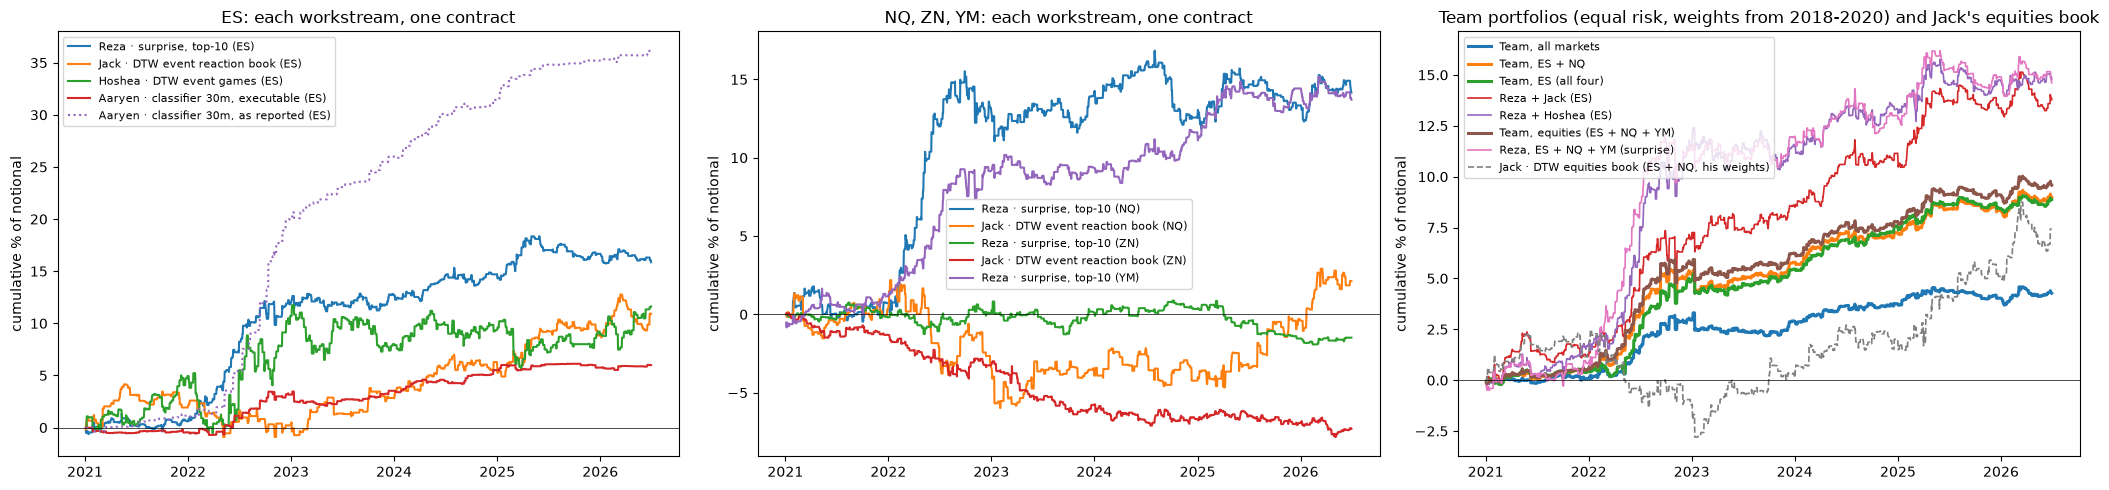

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for b in TEAM + ["Aaryen · classifier 30m, as reported (ES)"]:
    d = daily(b, TUNE_COST, DAYS["test"])
    axes[0].plot(d.index, d.cumsum() / 100, label=b, ls=":" if "as reported" in b else "-")
axes[0].set_title("ES: each workstream, one contract")
for b in OTHER:
    d = daily(b, TUNE_COST, DAYS["test"])
    axes[1].plot(d.index, d.cumsum() / 100, label=b)
axes[1].set_title(f"{', '.join(m for m in MARKETS if m != 'ES')}: each workstream, one contract")
for name, members in PORTFOLIOS.items():
    d = sum(weights[name][b] * daily(b, TUNE_COST, DAYS["test"]) for b in members)
    axes[2].plot(d.index, d.cumsum() / 100, label=name, lw=2.2 if name.startswith("Team") else 1.2)
d, _ = jack_equities_daily(TUNE_COST, DAYS["test"])
axes[2].plot(d.index, d.cumsum() / 100, label=JACK_EQ, lw=1.2, ls="--")
axes[2].set_title("Team portfolios (equal risk, weights from 2018-2020) and Jack's equities book")
for ax in axes:
    ax.axhline(0, c="k", lw=0.5)
    ax.set_ylabel("cumulative % of notional")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "team_book_cumulative.png", dpi=150)
plt.show()

In [13]:
pd.concat({"validation": tables["validation"], "test": tables["test"], "portfolios, test": port},
          names=["table", "book", "cost"]).to_csv(OUT / "team_book_summary.csv")
pd.concat(corr, names=["period", "book"]).to_csv(OUT / "team_book_correlation.csv")
print("wrote team_book_summary.csv, team_book_correlation.csv, team_book_cumulative.png")

wrote team_book_summary.csv, team_book_correlation.csv, team_book_cumulative.png


## 8. Team report: strategies only, no names

The same results as above, relabelled by **strategy** instead of by person, for a report
on the team's work as a whole, on every market where a strategy exists (ES, NQ, ZN). Nothing is recomputed: the tables and the figure re-use
sections 4-7. Aaryen's as-reported version is left out, because it is not tradeable.

| strategy | what it trades |
|---|---|
| **Macro-surprise book** | sign of the consensus surprise, top-10 release families plus CPI, one 30-minute window |
| **CPI surprise model** | CPI only, traded when the predicted move exceeds the cost |
| **DTW ladder book** | DTW price-path analogues, five back-to-back 30-minute windows after each print |
| **DTW event-game book** | DTW price-path analogues on Jobless Claims, JOLTS and PCE, windows before and after the print |
| **Machine-learning classifier** | a walk-forward classifier's position, one 30-minute window |

Outputs: `output/team_report_summary.csv`, `output/team_report_correlation.csv`,
`output/team_report_figure.png`, `output/team_report_summary.md`.

In [14]:
REBUILT = "rebuild" in JACK_SOURCE
BASE = {"Reza · surprise, top-10": "Macro-surprise book", "Reza · CPI surprise model": "CPI surprise model",
        "Jack · DTW event reaction book": "DTW ladder book" + (" (rebuilt)" if REBUILT else ""),
        "Hoshea · DTW event games": "DTW event-game book",
        "Aaryen · classifier 30m, executable": "Machine-learning classifier"}
LABELS = {b: f"{BASE[b[:-5]]}, {mkt_of(b)}" for b in books if b[:-5] in BASE}
PORT_LABELS = {
    "Team, all markets": "Team portfolio, all markets (ES + NQ + ZN)",
    "Team, ES + NQ": "Team portfolio, ES + NQ",
    "Team, ES (all four)": "Team portfolio, ES (four strategies)",
    "Reza + Jack (ES)": "Macro surprise + DTW ladder, ES",
    "Reza + Hoshea (ES)": "Macro surprise + DTW event games, ES",
    "Team, equities (ES + NQ + YM)": "Team portfolio, equities (ES + NQ + YM)",
    "Reza, ES + NQ + YM (surprise)": "Macro-surprise book, ES + NQ + YM",
    JACK_EQ: "DTW ladder book, ES + NQ (inverse vol + cost gate)",
}
PORT_LABELS = {k: v for k, v in PORT_LABELS.items() if k in PORTFOLIOS or k == JACK_EQ}
STRATS = TEAM_ALL + [f"Reza · CPI surprise model ({s})" for s in MARKETS]
n_test = (DAYS["test"].max() - DAYS["test"].min()).days / 365.25

rep = {}
for b in STRATS:
    r = {"trades / year": tables["test"].loc[(b, TUNE_COST), "trades"] / n_test}
    r |= {f"Sharpe, {c}": tables["test"].loc[(b, c), "sharpe"] for c in COSTS}
    r["Sharpe 2018-20, ¼ tick"] = tables["validation"].loc[(b, TUNE_COST), "sharpe"]
    r |= {f"{k}, ¼ tick": tables["test"].loc[(b, TUNE_COST), k] for k in ["total %", "ann vol %", "max DD %"]}
    rep[LABELS[b]] = r
for name in list(PORTFOLIOS) + [JACK_EQ]:
    r = {"trades / year": port.loc[(name, TUNE_COST), "trades"] / n_test}
    r |= {f"Sharpe, {c}": port.loc[(name, c), "sharpe"] for c in COSTS}
    r["Sharpe 2018-20, ¼ tick"] = np.nan                     # weights fitted on 2018-2020 (Jack's: walk-forward, test years only)
    r |= {f"{k}, ¼ tick": port.loc[(name, TUNE_COST), k] for k in ["total %", "ann vol %", "max DD %"]}
    rep[PORT_LABELS[name]] = r
for m in MARKETS:
    x = tables["test"].loc[(f"{m} buy and hold", "buy and hold")]
    rep[f"{m} buy and hold"] = {"Sharpe, gross": x["sharpe"], "total %, ¼ tick": x["total %"],
                                "ann vol %, ¼ tick": x["ann vol %"], "max DD %, ¼ tick": x["max DD %"],
                                "Sharpe 2018-20, ¼ tick": tables["validation"].loc[(f"{m} buy and hold", "buy and hold"), "sharpe"]}
bh = tables["test"].loc[("ES buy and hold", "buy and hold")]
report = pd.DataFrame(rep).T
from IPython.display import Markdown, display

Q, HC = f"Sharpe, {TUNE_COST}", "Sharpe, 2 ticks + $4.50"
STRAT_ORDER = [BASE[k] for k in BASE]
ABBR = {"Macro-surprise book": "Surprise", "CPI surprise model": "CPI model",
        BASE["Jack · DTW event reaction book"]: "DTW ladder", "DTW event-game book": "DTW games",
        "Machine-learning classifier": "Classifier"}


def split_label(label: str) -> tuple[str, str]:
    name, mkt = label.rsplit(", ", 1)
    return name, mkt


def show(df: pd.DataFrame, title: str, fmt: dict, note: str = "", gradient: list | None = None,
         vmin=-1.0, vmax=1.5, cmap="RdYlGn"):
    display(Markdown("---\n\n" + f"#### {title}" + (f"\n\n{note}" if note else "")))
    sty = (df.style.format(fmt, na_rep="–")
           .set_table_attributes('style="border-collapse: collapse; margin-bottom: 1em"')
           .set_table_styles([
               {"selector": "th, td", "props": [("border", "1px solid #9CA3AF"), ("padding", "4px 10px"),
                                                ("text-align", "center")]},
               {"selector": "th.row_heading", "props": [("text-align", "left")]},
               {"selector": "thead th", "props": [("background-color", "#003262"), ("color", "white")]},
           ]))
    if gradient:
        sty = sty.background_gradient(cmap=cmap, subset=gradient, vmin=vmin, vmax=vmax)
    sty = sty.highlight_null(props="background-color: #F3F4F6; color: #6B7280")
    display(sty)


# ---- Table 1: Sharpe at a glance, strategy x market
glance = pd.DataFrame(index=STRAT_ORDER, columns=MARKETS, dtype=float)
for b in STRATS:
    name, mkt = split_label(LABELS[b])
    glance.loc[name, mkt] = report.loc[LABELS[b], Q]
glance.index.name = "Strategy"
show(glance, "1. Sharpe at a glance (test years 2021–2026, ¼ tick per side)",
     {m: "{:.2f}" for m in MARKETS}, "“–” = the strategy does not exist on that market.",
     gradient=MARKETS)

# ---- Table 2: team portfolios
PCOLS = {"Sharpe, gross": "Sharpe gross", Q: "Sharpe ¼ tick", "Sharpe, half tick": "Sharpe ½ tick",
         HC: "Sharpe 2 ticks + $4.50", "total %, ¼ tick": "Return %", "ann vol %, ¼ tick": "Vol %",
         "max DD %, ¼ tick": "Max DD %", "trades / year": "Trades / yr"}
ports = report.loc[list(PORT_LABELS.values()), list(PCOLS)].rename(columns=PCOLS)
ports.index.name = "Portfolio"
show(ports, "2. Team portfolios (equal risk, weights from 2018–2020) and the DTW equities book (test years 2021–2026)",
     {**{c: "{:.2f}" for c in ports.columns}, "Return %": "{:+.1f}", "Vol %": "{:.1f}",
      "Max DD %": "{:.1f}", "Trades / yr": "{:,.0f}"},
     "Return, volatility and drawdown are at ¼ tick per side.",
     gradient=["Sharpe gross", "Sharpe ¼ tick", "Sharpe ½ tick", "Sharpe 2 ticks + $4.50"])

# ---- Table 3: each strategy in detail, grouped by market
DCOLS = {"trades / year": "Trades / yr", Q: "Sharpe ¼ tick", HC: "Sharpe 2 ticks + $4.50",
         "Sharpe 2018-20, ¼ tick": "Sharpe 2018–20", "total %, ¼ tick": "Return %",
         "ann vol %, ¼ tick": "Vol %", "max DD %, ¼ tick": "Max DD %"}
det = report.loc[[LABELS[b] for b in STRATS], list(DCOLS)].rename(columns=DCOLS)
det.index = pd.MultiIndex.from_tuples([split_label(i)[::-1] for i in det.index], names=["Market", "Strategy"])
det = det.sort_index(level=0, sort_remaining=False)
show(det, "3. Each strategy in detail (test years 2021–2026)",
     {"Trades / yr": "{:,.0f}", "Sharpe ¼ tick": "{:.2f}", "Sharpe 2 ticks + $4.50": "{:.2f}",
      "Sharpe 2018–20": "{:.2f}", "Return %": "{:+.1f}", "Vol %": "{:.1f}", "Max DD %": "{:.1f}"},
     "Return, volatility and drawdown are at ¼ tick per side; “Sharpe 2018–20” is the validation years.",
     gradient=["Sharpe ¼ tick", "Sharpe 2 ticks + $4.50", "Sharpe 2018–20"])

# ---- Table 4: buy and hold, for reference
bh_tab = report.loc[[f"{m} buy and hold" for m in MARKETS],
                    ["Sharpe, gross", "Sharpe 2018-20, ¼ tick", "total %, ¼ tick", "ann vol %, ¼ tick", "max DD %, ¼ tick"]]
bh_tab.columns = ["Sharpe 2021–26", "Sharpe 2018–20", "Return %", "Vol %", "Max DD %"]
bh_tab.index = MARKETS
bh_tab.index.name = "Buy and hold"
show(bh_tab, "4. Buy and hold, for reference (one contract, no costs)",
     {"Sharpe 2021–26": "{:.2f}", "Sharpe 2018–20": "{:.2f}", "Return %": "{:+.1f}", "Vol %": "{:.1f}",
      "Max DD %": "{:.1f}"})

# ---- Table 5: correlation
rep_corr = corr["test"].rename(index=LABELS, columns=LABELS)
short_lab = {l: f"{ABBR[split_label(l)[0]]} {split_label(l)[1]}" for l in rep_corr.index}
corr_show = rep_corr.rename(index=short_lab, columns=short_lab)
show(corr_show, "5. How much the strategies move together (correlation of daily P&L, 2021–2026)",
     {c: "{:.2f}" for c in corr_show.columns},
     "Near 0 = the two strategies make and lose money on different days, so combining them lowers risk.",
     gradient=list(corr_show.columns), vmin=-1, vmax=1, cmap="coolwarm")

---

#### 1. Sharpe at a glance (test years 2021–2026, ¼ tick per side)

“–” = the strategy does not exist on that market.

,ES,NQ,ZN,YM
Strategy,,,,
Macro-surprise book,1.09,0.75,-0.16,1.06
CPI surprise model,0.51,0.46,0.17,0.39
DTW ladder book,0.64,0.11,-0.97,–
DTW event-game book,0.42,–,–,–
Machine-learning classifier,0.95,–,–,–


---

#### 2. Team portfolios (equal risk, weights from 2018–2020) and the DTW equities book (test years 2021–2026)

Return, volatility and drawdown are at ¼ tick per side.

,Sharpe gross,Sharpe ¼ tick,Sharpe ½ tick,Sharpe 2 ticks + $4.50,Return %,Vol %,Max DD %,Trades / yr
Portfolio,,,,,,,,
"Team portfolio, all markets (ES + NQ + ZN)",1.35,0.83,0.30,-1.09,+4.3,1.0,-1.1,"1,562"
"Team portfolio, ES + NQ",1.45,1.31,1.17,0.78,+9.0,1.3,-1.1,"1,043"
"Team portfolio, ES (four strategies)",1.55,1.39,1.22,0.76,+8.9,1.2,-1.0,739
"Macro surprise + DTW ladder, ES",1.31,1.16,1.01,0.59,+13.8,2.2,-2.0,315
"Macro surprise + DTW event games, ES",1.32,1.14,0.96,0.46,+14.8,2.4,-2.2,465
"Team portfolio, equities (ES + NQ + YM)",1.48,1.35,1.22,0.85,+9.6,1.3,-1.1,"1,131"
"Macro-surprise book, ES + NQ + YM",1.13,1.07,1.01,0.82,+14.6,2.6,-2.4,280
"DTW ladder book, ES + NQ (inverse vol + cost gate)",0.66,0.54,0.42,0.07,+7.4,2.6,-5.3,427


---

#### 3. Each strategy in detail (test years 2021–2026)

Return, volatility and drawdown are at ¼ tick per side; “Sharpe 2018–20” is the validation years.

---

#### 4. Buy and hold, for reference (one contract, no costs)

,Sharpe 2021–26,Sharpe 2018–20,Return %,Vol %,Max DD %
Buy and hold,,,,,
ES,0.69,0.80,+62.4,16.9,-31.1
NQ,0.58,1.16,+70.6,22.9,-48.3
ZN,-0.69,0.86,-23.0,6.2,-25.7
YM,0.67,0.54,+52.4,14.9,-25.6


---

#### 5. How much the strategies move together (correlation of daily P&L, 2021–2026)

Near 0 = the two strategies make and lose money on different days, so combining them lowers risk.

,Surprise ES,DTW ladder ES,DTW games ES,Classifier ES,Surprise NQ,DTW ladder NQ,Surprise ZN,DTW ladder ZN,Surprise YM
Surprise ES,1.00,0.13,-0.01,0.27,0.68,-0.03,0.10,0.02,0.85
DTW ladder ES,0.13,1.00,-0.04,0.17,0.06,0.15,0.16,-0.00,0.15
DTW games ES,-0.01,-0.04,1.00,-0.02,-0.02,0.05,0.00,0.04,-0.01
Classifier ES,0.27,0.17,-0.02,1.00,0.26,0.12,0.31,0.04,0.23
Surprise NQ,0.68,0.06,-0.02,0.26,1.00,0.02,0.11,0.03,0.51
DTW ladder NQ,-0.03,0.15,0.05,0.12,0.02,1.00,0.00,0.00,-0.07
Surprise ZN,0.10,0.16,0.00,0.31,0.11,0.00,1.00,-0.02,0.12
DTW ladder ZN,0.02,-0.00,0.04,0.04,0.03,0.00,-0.02,1.00,0.04
Surprise YM,0.85,0.15,-0.01,0.23,0.51,-0.07,0.12,0.04,1.00


### Team report figure

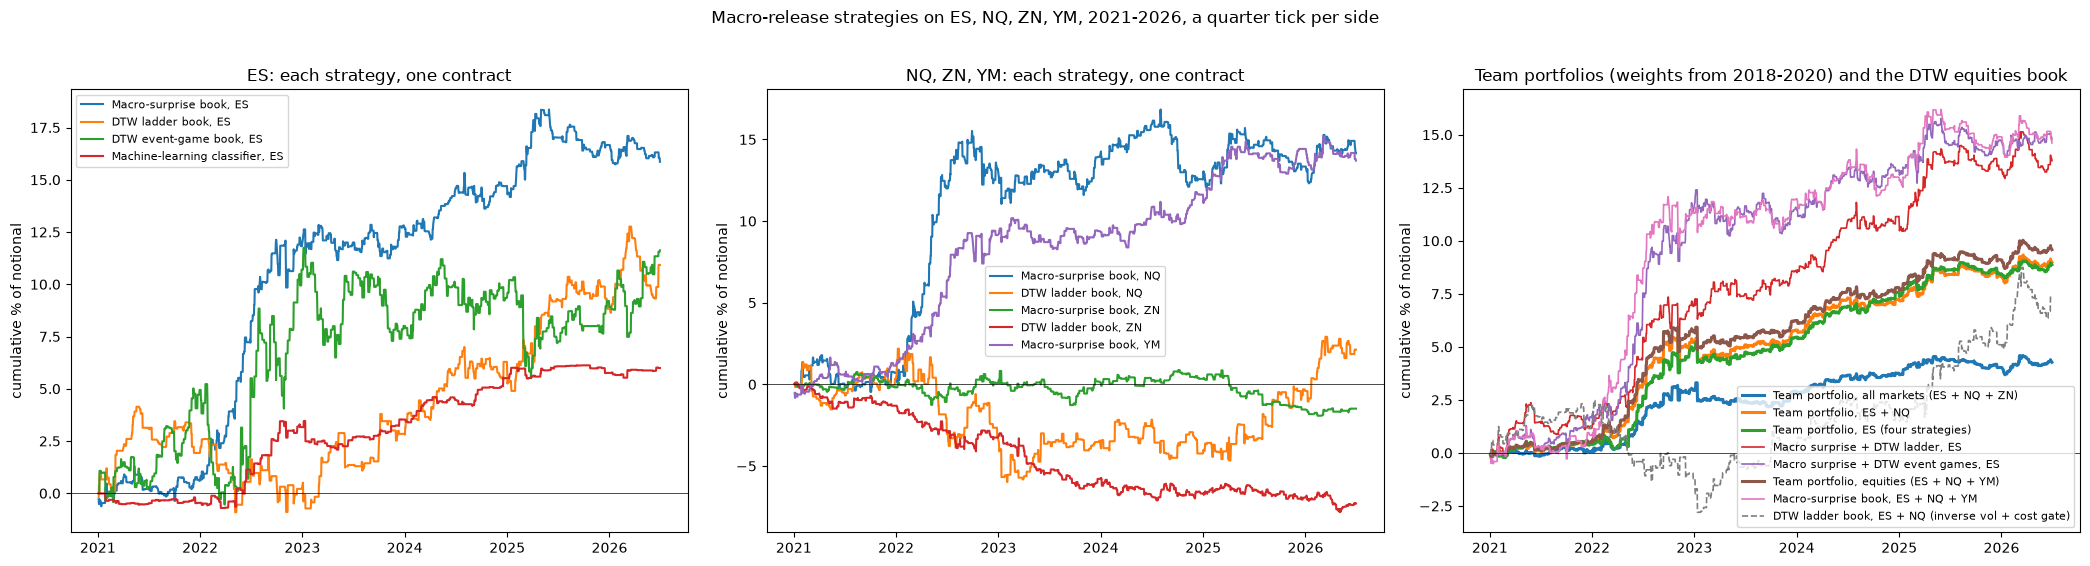

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))
for b in TEAM:
    d = daily(b, TUNE_COST, DAYS["test"])
    axes[0].plot(d.index, d.cumsum() / 100, label=LABELS[b])
axes[0].set_title("ES: each strategy, one contract")
for b in OTHER:
    d = daily(b, TUNE_COST, DAYS["test"])
    axes[1].plot(d.index, d.cumsum() / 100, label=LABELS[b])
axes[1].set_title(f"{', '.join(m for m in MARKETS if m != 'ES')}: each strategy, one contract")
for name, members in PORTFOLIOS.items():
    d = sum(weights[name][b] * daily(b, TUNE_COST, DAYS["test"]) for b in members)
    axes[2].plot(d.index, d.cumsum() / 100, label=PORT_LABELS[name], lw=2.2 if name.startswith("Team") else 1.2)
d, _ = jack_equities_daily(TUNE_COST, DAYS["test"])
axes[2].plot(d.index, d.cumsum() / 100, label=PORT_LABELS[JACK_EQ], lw=1.2, ls="--")
axes[2].set_title("Team portfolios (weights from 2018-2020) and the DTW equities book")
for ax in axes:
    ax.axhline(0, c="k", lw=0.5)
    ax.set_ylabel("cumulative % of notional")
    ax.legend(fontsize=8)
fig.suptitle(f"Macro-release strategies on {', '.join(MARKETS)}, 2021-2026, a quarter tick per side", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "team_report_figure.png", dpi=150, bbox_inches="tight")
plt.show()

### Team report summary

Written from the numbers above, so it stays correct if the notebook is re-run (for
example with the exact DTW ladder book from `features.py`).

In [16]:
q, hc = f"Sharpe, {TUNE_COST}", "Sharpe, 2 ticks + $4.50"
S = report.loc[[LABELS[b] for b in TEAM_ALL]]
T_all, T_en, T_es = (report.loc[PORT_LABELS[k]] for k in ["Team, all markets", "Team, ES + NQ", "Team, ES (all four)"])
cvals = rep_corr.where(~np.eye(len(rep_corr), dtype=bool)).stack()
fast = [LABELS[b] for b in TEAM if report.loc[LABELS[b], "trades / year"] > 200]
zn = S[[i.endswith("ZN") for i in S.index]]
es_names = ", ".join(LABELS[b].rsplit(",", 1)[0] for b in TEAM)
EXTRA_LINE = ""
if "YM" in MARKETS:
    T_eq, R_eq = report.loc[PORT_LABELS["Team, equities (ES + NQ + YM)"]], report.loc[PORT_LABELS["Reza, ES + NQ + YM (surprise)"]]
    EXTRA_LINE = (f"; equities ES + NQ + YM {T_eq[q]:.2f} ({T_eq['max DD %, ¼ tick']:.1f}%); "
                  f"the macro-surprise book on ES + NQ + YM {R_eq[q]:.2f} ({R_eq['max DD %, ¼ tick']:.1f}%)")
summary = f"""**Team results, 2021-2026 (validation 2018-2020): the same data, entry and costs for every strategy.**

- Coverage: on ES four strategies were tested ({es_names}); on NQ and ZN the two that exist there (macro-surprise and DTW ladder){"; on YM the macro-surprise book" if "YM" in MARKETS else ""}.
- At a quarter tick per side the strategies' Sharpe ratios range from {S[q].min():.2f} ({S[q].idxmin()}) to {S[q].max():.2f} ({S[q].idxmax()}); ES buy-and-hold scores {bh['sharpe']:.2f} with a {bh['max DD %']:.0f}% maximum drawdown.
- The strategies carry different risks: daily P&L correlations between them range from {cvals.min():.2f} to {cvals.max():.2f}.
- Team portfolios (equal risk, weights from 2018-2020), at a quarter tick: all markets {T_all[q]:.2f} (max drawdown {T_all['max DD %, ¼ tick']:.1f}%), ES + NQ {T_en[q]:.2f} ({T_en['max DD %, ¼ tick']:.1f}%), ES only {T_es[q]:.2f} ({T_es['max DD %, ¼ tick']:.1f}%){EXTRA_LINE}.
- The DTW ladder book on ES + NQ with its own weights (inverse vol + cost gate) scores {report.loc[PORT_LABELS[JACK_EQ], q]:.2f} at a quarter tick and {report.loc[PORT_LABELS[JACK_EQ], hc]:.2f} at 2 ticks + $4.50.
- Execution cost decides the result: at 2 ticks + $4.50 the team portfolios score {T_all[hc]:.2f} (all markets), {T_en[hc]:.2f} (ES + NQ) and {T_es[hc]:.2f} (ES), because {" and ".join(fast) if fast else "the higher-turnover strategies"} trade{"s" if len(fast) == 1 else ""} more than 200 times a year. On ZN the strategies score {", ".join(f"{v:.2f}" for v in zn[hc])} at that cost.
- Caveats: the DTW event-game setting was chosen on the full sample, the test years have been examined before, and a large part of the gains comes from 2022."""
display(Markdown(summary))
(OUT / "team_report_summary.md").write_text(summary + "\n")
report.to_csv(OUT / "team_report_summary.csv")
rep_corr.to_csv(OUT / "team_report_correlation.csv")
print("\nwrote team_report_summary.csv, team_report_correlation.csv, team_report_figure.png, team_report_summary.md")

**Team results, 2021-2026 (validation 2018-2020): the same data, entry and costs for every strategy.**

- Coverage: on ES four strategies were tested (Macro-surprise book, DTW ladder book, DTW event-game book, Machine-learning classifier); on NQ and ZN the two that exist there (macro-surprise and DTW ladder); on YM the macro-surprise book.
- At a quarter tick per side the strategies' Sharpe ratios range from -0.97 (DTW ladder book, ZN) to 1.09 (Macro-surprise book, ES); ES buy-and-hold scores 0.69 with a -31% maximum drawdown.
- The strategies carry different risks: daily P&L correlations between them range from -0.07 to 0.85.
- Team portfolios (equal risk, weights from 2018-2020), at a quarter tick: all markets 0.83 (max drawdown -1.1%), ES + NQ 1.31 (-1.1%), ES only 1.39 (-1.0%); equities ES + NQ + YM 1.35 (-1.1%); the macro-surprise book on ES + NQ + YM 1.07 (-2.4%).
- The DTW ladder book on ES + NQ with its own weights (inverse vol + cost gate) scores 0.54 at a quarter tick and 0.07 at 2 ticks + $4.50.
- Execution cost decides the result: at 2 ticks + $4.50 the team portfolios score -1.09 (all markets), 0.78 (ES + NQ) and 0.76 (ES), because DTW ladder book, ES and DTW event-game book, ES trade more than 200 times a year. On ZN the strategies score -1.51, -5.03 at that cost.
- Caveats: the DTW event-game setting was chosen on the full sample, the test years have been examined before, and a large part of the gains comes from 2022.


wrote team_report_summary.csv, team_report_correlation.csv, team_report_figure.png, team_report_summary.md
